In [ ]:
# Import
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [2]:
# example signal
original_waveform = np.sin(np.linspace(0,221,400))
_,_,original_spectrogram = scipy.signal.stft(original_waveform,nperseg=100, return_onesided=True)
frames = original_spectrogram.shape[1]

# initialize target magnitude spectrogram
magnitude_spectrogram = np.abs(original_spectrogram)

# initial guess of complex spectrogram = random phase
spectrogram = magnitude_spectrogram*np.exp(1j*2*np.pi*np.random.rand(51,frames)) 

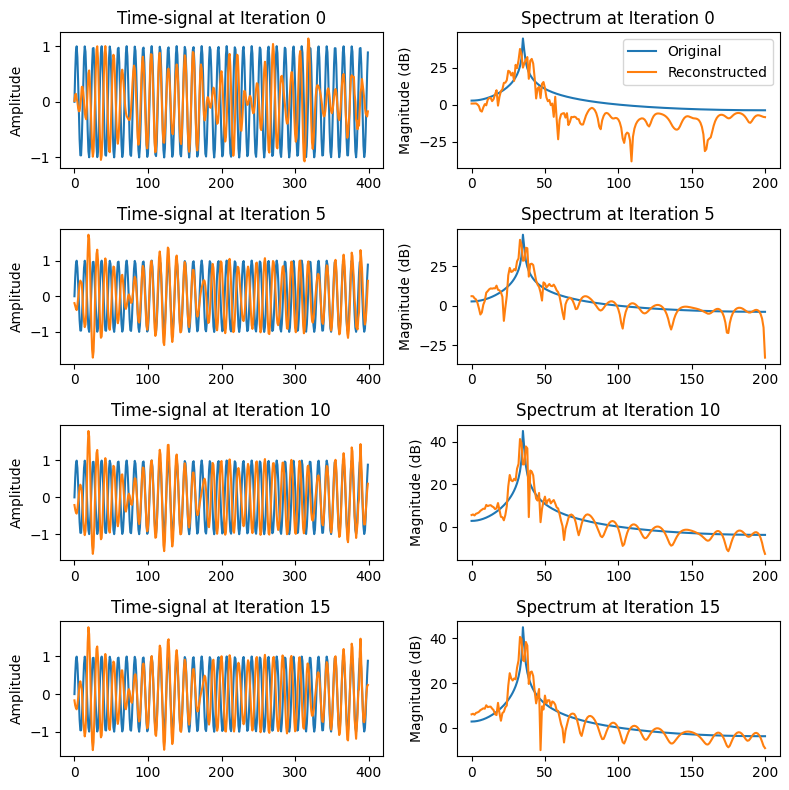

In [3]:
plt.figure(figsize=(8,8))
N = 4
K = 5
for h in range(N*K - K+1):
    _,waveform = scipy.signal.istft(spectrogram, nperseg=100, input_onesided =True, boundary=True)
    waveform = np.real(waveform)
    _,_,spectrogram = scipy.signal.stft(waveform,    nperseg=100, return_onesided=True)
    spectrogram = np.exp(1j*np.angle(spectrogram))*magnitude_spectrogram
    
    if h % K == 0:
        k = h//K
        plt.subplot(N,2,2*k+1)
        plt.plot(original_waveform)
        plt.plot(waveform)
        plt.title(f"Time-signal at Iteration {h}")
        plt.ylabel('Amplitude')
        
        plt.subplot(N,2,2*k+2)
        plt.plot(20*np.log10(np.abs(scipy.fft.rfft(original_waveform))),label='Original')
        plt.plot(20*np.log10(np.abs(scipy.fft.rfft(waveform))),label='Reconstructed')
        plt.title(f"Spectrum at Iteration {h}")
        plt.ylabel('Magnitude (dB)')
        if h==0: plt.legend()
        
    
plt.tight_layout()
plt.show()

In [4]:
# example signal
original_waveform = np.sin(np.linspace(0,17,400))
_,_,original_spectrogram = scipy.signal.stft(original_waveform,nperseg=100, return_onesided=True)
frames = original_spectrogram.shape[1]

# initialize target magnitude spectrogram
magnitude_spectrogram = np.abs(original_spectrogram)

# initial guess of complex spectrogram = random phase
spectrogram = magnitude_spectrogram*np.exp(1j*2*np.pi*np.random.rand(51,frames)) 

----------

In [6]:
# Initialization for all
from scipy.io import wavfile
import scipy
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd


filename = '/app/Simple-TTS/datasets/LJSpeech-1.1/wavs/LJ001-0001.wav'


# read from storage
fs, data = wavfile.read(filename)

seconds = 5  # Duration of recording
window_length_ms=30
window_length = int(window_length_ms*fs/2000)*2

In [7]:
# example signal
_,_,original_spectrogram = scipy.signal.stft(
    data,
    nperseg=window_length, 
    return_onesided=True)
frames = original_spectrogram.shape[1]
frequency_elements = original_spectrogram.shape[0]

# initialize target magnitude spectrogram
magnitude_spectrogram = np.abs(original_spectrogram)

# initial guess of complex spectrogram = random phase
spectrogram = magnitude_spectrogram*np.exp(1j*2*np.pi*np.random.rand(frequency_elements,frames)) 

In [8]:
for h in range(32):
    _,waveform = scipy.signal.istft(
        spectrogram, 
        nperseg=window_length, 
        input_onesided =True, 
        boundary=True)
    waveform = np.real(waveform)
    _,_,spectrogram = scipy.signal.stft(
        waveform,    
        nperseg=window_length, 
        return_onesided=True)
    spectrogram = np.exp(1j*np.angle(spectrogram))*magnitude_spectrogram
    
_,waveform = scipy.signal.istft(
        spectrogram, 
        nperseg=window_length, 
        input_onesided =True, 
        boundary=True)
waveform = np.real(waveform)

In [9]:
ipd.display(ipd.HTML('Original'))
ipd.display(ipd.Audio(data,rate=fs))
ipd.display(ipd.HTML('Reconstructed'))
ipd.display(ipd.Audio(waveform,rate=fs))